# Diseño e Implementación de un Sistema de Comunicación LoRa

***

##### **Asignatura:** Comunicaciones Digitales
##### **Docentes:** Corral Briones, Graciela — Ayarde, J. Martín
##### **Alumnos:** Graham, Enrique Lenox — Mamani, Franco Iván
##### **Grupo:** LenoxLegends
##### **Año de Cursado:** 2024

***

## Introducción

En este Trabajo Práctico Integrador construimos un sistema de comunicación LoRa **bloque por bloque**, partiendo del codec (bits ↔ símbolos), pasando por el modulador y los canales (AWGN + multipath), y terminando con la implementación del sistema completo sobre hardware real.

La modulación se basa en **chirps** — señales cuya frecuencia barre todo el ancho de banda durante un símbolo. A lo largo del trabajo vamos a ver por qué esa estructura resulta robusta frente al ruido y a la distorsión introducida por el canal.

Cada bloque se valida aisladamente: el codec con un round-trip de BER = 0, el waveformer + n-tuple former con SER = 0 sin canal, luego el sistema completo con canal AWGN y canal selectivo en frecuencia en simulación comparando las curvas BER vs SNR contra la Figura 1 del paper de Vangelista (2017) y finalmente el sistema sobre SDR confirmando que se recuperan los símbolos transmitidos. La justificacion teorica del receptor optimo viene del Rimoldi: El capitulo 2 desarrolla la desicion MAP/ML para observaciones discretas en AWGN, y el capitulo 3 muestra como el receptor de una señal continua puede reducirse a observaciones discretas mediante el n-tuple former.


## Bloques del sistema

El sistema sigue el esquema clásico de un sistema de comunicación digital (Rimoldi 2016, Cap 1):

![Diagrama de un sistema de comunicación digital](rimoldi_sistema.png)

**Transmisor:**
- **Encoder (Codec):** convierte bits en símbolos enteros.
- **Waveform Former:** convierte cada símbolo en un chirp complejo (modulación FSCM — *Frequency Shift Chirp Modulation*).

**Canal:**
- Suma **ruido AWGN** (térmico, gaussiano blanco aditivo).
- Introduce **distorsión multipath** modelada como un filtro selectivo en frecuencia.

**Receptor:**
- **n-Tuple Former:** demodula el chirp recibido mediante *dechirp + FFT + argmax*, recuperando el símbolo más probable (criterio ML).
- **Decoder:** convierte el símbolo de vuelta a bits.

## Alcance del Trabajo

El trabajo se divide en dos partes complementarias:

- **Parte 1 — Implementación Software (Vangelista 2017, Módulos 1-4):** sistema TX/RX completo en simulación, validado contra las curvas BER/SER del paper.
- **Parte 2 — SDR (Módulo 5.1):** implementación del sistema sobre hardware real (PlutoSDR) en modo loopback.

Este notebook integra los cinco módulos del sistema:
:

| Módulo | Contenido | Bloque del sistema |
|---|---|---|
| **1 — Codec** | Codificador y decodificador bits ↔ símbolos según Ec. (1) de Vangelista | Encoder / Decoder |
| **2 — Waveform Former** | Generación de chirps según Ec. (3) y demodulación óptima (Sección III) | Waveform Former / n-Tuple Former |
| **3 — Canal AWGN** | Ruido térmico y curvas BER/SER vs SNR comparadas con la Figura 1 del paper | Canal (ruido) |
| **4 — Canal Selectivo** | Multipath con respuesta $h(nT) = \sqrt{0.8}\,\delta(nT) + \sqrt{0.2}\,\delta(nT-T)$ | Canal (distorsión) |
| **5 — SDR Loopback** | TX/RX completo sobre un único PlutoSDR (loopback digital y por antena) | Sistema completo en hardware |


**Criterio de validación (Parte 1):** las curvas BER/SER simuladas vía Monte Carlo deben aproximarse a las curvas FSCM-Flat y FSCM-Frequency-Selective publicadas en Vangelista (2017).

**Criterio de validación (Parte 2):** el sistema debe recuperar correctamente los símbolos transmitidos en loopback sobre PlutoSDR.


## Referencias

[1] **Vangelista, L.** (2017). *Frequency Shift Chirp Modulation: The LoRa Modulation*.

[2] **Rimoldi, B.** (2016). *Principles of Digital Communication: A Top-Down Approach*.

---

## Configuración inicial — Imports y parámetros globales

### Parámetros fundamentales del sistema LoRa

| Parámetro | Símbolo | Valor | Descripción |
|---|---|---|---|
| **Spreading Factor** | $SF$ | 7 | Cantidad de bits por símbolo. Define el rango de símbolos posibles: $s \in \{0, 1, \dots, 2^{SF}-1\}$. |
| **Tamaño del alfabeto** | $M = 2^{SF}$ | 128 | Cantidad de chirps distintos = cantidad de muestras (chips) por símbolo. |
| **Ancho de banda** | $BW$ | 125 kHz | Ancho de banda del canal. |
| **Frecuencia de muestreo** | $f_s$ | $BW$ = 125 kHz | Una muestra por chip. |
| **Período de chip** | $T = 1/BW$ | 8 μs | Duración de cada chip (muestra) dentro del símbolo. |
| **Período de símbolo** | $T_s = M \cdot T$ | 1.024 ms | Duración total de un símbolo (128 chips × 8 μs). |

> Cada parámetro se profundiza en el módulo donde aparece, esta tabla es solo una referencia rápida.


### Imports y declaración de parámetros

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread 
import matplotlib.gridspec as gridspec 

# === Parámetros globales del sistema LoRa ===
SF = 7              # Spreading Factor (bits por símbolo)
M  = 2 ** SF        # Tamaño del alfabeto = chips por símbolo (= 128)
BW = 125e3          # Ancho de banda [Hz]
fs = BW             # Frecuencia de muestreo [Hz]
T  = 1 / BW         # Período de chip [s]
Ts = M / BW         # Duración del símbolo [s]

print("Parámetros globales:")
print(f"  SF = {SF}")
print(f"  M  = {M} (símbolos / chips por símbolo)")
print(f"  BW = {BW/1e3:.0f} kHz")
print(f"  fs = {fs/1e3:.0f} kHz")
print(f"  T  = {T*1e6:.2f} us")
print(f"  Ts = {Ts*1e3:.3f} ms")


Parámetros globales:
  SF = 7
  M  = 128 (símbolos / chips por símbolo)
  BW = 125 kHz
  fs = 125 kHz
  T  = 8.00 us
  Ts = 1.024 ms


# Módulo 1 — Codec (Codificador / Decodificador)

En esta primera parte implementamos el primer bloque de la capa física: el **codec**, que convierte un flujo de bits en una secuencia de símbolos enteros, y reconstruye los bits a partir de esos símbolos.

---

## 1. Conceptos básicos

Un **símbolo** es la unidad de información que se transmite por el canal en cada **período de símbolo** $T_s$ (la duración de un símbolo). Se elige de un alfabeto finito $\mathcal{H} = \{0, 1, \ldots, M-1\}$.

El **Spreading Factor (SF)** define dos cosas en LoRa:

- Cuántos bits cargo en cada símbolo: $SF$ bits.
- Tamaño del alfabeto: $M = 2^{SF}$..

### Ejemplo:

Si los bits fueran `0 1 0 0 1 0 0 0 0 1 0 0 1 1 1 1` (16 bits). Con SF=4 los agrupo de a 4 y convierto cada grupo a entero usando la **convención LSB-first del paper de Vangelista** (el primer bit del grupo pesa $2^0=1$, el último $2^{SF-1}$):

| Grupo (4 bits) | Cálculo (LSB-first) | Decimal |
|----------------|---------------------|---------|
| `0100` | $0·1 + 1·2 + 0·4 + 0·8$ | 2 |
| `1000` | $1·1 + 0·2 + 0·4 + 0·8$ | 1 |
| `0100` | $0·1 + 1·2 + 0·4 + 0·8$ | 2 |
| `1111` | $1·1 + 1·2 + 1·4 + 1·8$ | 15 |

**Resultado:** 16 bits → 4 símbolos `[2, 1, 2, 15]`.

## 2. Diseño del codec

### Codificación: de bits a símbolos

El codificador se basa en la **ecuación (1) del paper de Vangelista (2017)**, que define formalmente cómo se mapea un bloque de SF bits a un símbolo entero:

$$s(nT_s) = \sum_{h=0}^{SF-1} w(nT_s)_h \cdot 2^h \quad \quad \quad \quad \quad \text{(1)}$$

**Variables:**

- $s(nT_s)$: símbolo resultante (entero en el rango $[0, 2^{SF}-1]$).
- $w(nT_s)_h$: bit en la posición $h$ del bloque ($w_h \in \{0, 1\}$).
- $SF$: Spreading Factor (cantidad de bits por símbolo).
- $nT_s$: instante temporal del símbolo número $n$. Es notación de tiempo discreto: $T_s$ es la duración de un símbolo, y $n$ es el índice.

**Convención LSB-first**: el bit en posición $h$ pesa $2^h$. El primer bit del bloque vale $2^0=1$, el último vale $2^{SF-1}$.

### Aplicación al ejemplo SF=4

Para el bloque $w = [0, 1, 0, 0]$ con SF=4:

| $h$ | $w_h$ | $2^h$ | $w_h \cdot 2^h$ |
|-----|-------|-------|-------------------|
| 0 | 0 | 1 | 0 |
| 1 | 1 | 2 | 2 |
| 2 | 0 | 4 | 0 |
| 3 | 0 | 8 | 0 |

Suma: $s = 0 + 2 + 0 + 0 = 2$

### Decodificación: de símbolo a bits

La fórmula del decoder no aparece en el paper de Vangelista — el paper solo define el encoder (Ec. 1). Pero es basicamente la inversa matemática de la Eq. (1):

$$w_h = \lfloor s \,/\, 2^h \rfloor \bmod 2 \;=\; (s \gg h) \,\&\, 1$$

para $h = 0, 1, \ldots, SF-1$.

**Variables:**
- $w_h$: bit recuperado en la posición $h$.
- $s$: símbolo entero del que queremos extraer los bits.
- $\bmod 2$: operador de módulo 2 (resto de la división entera por 2).


### Ejemplo con SF=4

Para verificar que el decoder es la inversa exacta del encoder, decodificamos el símbolo $s = 2$ que obtuvimos arriba (con SF=4) y comprobamos que recuperamos el bloque original $w = [0, 1, 0, 0]$:

| $h$ | $\lfloor s / 2^h \rfloor$ | $w_h = \lfloor s / 2^h \rfloor \bmod 2$ |
|-----|---------------------------|-----------------------------------------|
| 0 | $\lfloor 2/1 \rfloor = 2$ | $2 \bmod 2 = 0$ |
| 1 | $\lfloor 2/2 \rfloor = 1$ | $1 \bmod 2 = 1$ |
| 2 | $\lfloor 2/4 \rfloor = 0$ | $0 \bmod 2 = 0$ |
| 3 | $\lfloor 2/8 \rfloor = 0$ | $0 \bmod 2 = 0$ |


Bloque recuperado: $w = [0, 1, 0, 0]$  — coincide con el bloque original que entró al encoder. El round-trip cierra perfectamente.

## 3. Bit Error Rate (BER)

El **Bit Error Rate (BER)** se define como:

$$\text{BER} = \frac{\text{cantidad de bits erróneos}}{\text{cantidad de bits transmitidos}}$$

Sin canal, esperamos **BER = 0** en cualquier round-trip (encoder → decoder). Cuando agreguemos ruido AWGN en el Módulo 3, la BER va a aumentar y vamos a compararla contra las curvas publicadas en el paper de Vangelista (2017), Figura 1.


## 4. Implementación

### `bits_to_symbols(bits, SF)` — codificador

In [3]:
def bits_to_symbols(bits, SF):
    #1-Verificamos que len(bits) sea múltiplo de SF
    if len(bits) % SF != 0:
        raise ValueError(f"len(bits)={len(bits)} no es múltiplo de SF={SF}")
    
    #2- Reshape a matriz (n_simbolos, SF)
    n_simbolos = len(bits) // SF
    matriz = bits.reshape(n_simbolos, SF)
    
    #3- Crear vector de pesos para convertir bits a símbolos
    pesos = 2 ** np.arange(SF) 
    
    # Paso 4: Producto matricial → símbolos
    simbolos = matriz @ pesos
    
    return simbolos

### `symbols_to_bits(symbols, SF)` — decodificador

In [4]:
def symbols_to_bits(symbols, SF):
    #1-Reshape a matriz (n_simbolos, 1)
    symbols_col = symbols.reshape(-1, 1)

    #2- Creamos vector de shifts LBS-MSB
    shifts = np.arange(SF)

    #3- Desplazamos bits a la derecha y aplicamos AND para extraer cada bit
    matriz = (symbols_col >> shifts) & 1

    # Paso 4: Aplanar a vector 1D
    bits = matriz.flatten() 
    
    return bits

### `calcular_ber(bits_tx, bits_rx)` — métrica de errores

In [5]:
def calcular_ber(bits_tx, bits_rx):
    errores = np.sum(bits_tx != bits_rx)
    ber = errores / len(bits_tx)
    return ber

## 5. Tests

In [6]:

def test_round_trip(num_bits, SF):

    print(f"TEST: {num_bits} bits aleatorios (SF={SF})")

    # Generar bits aleatorios
    
    bits_tx = np.random.randint(0, 2, num_bits)
    #bits_tx = np.array([0,1,0,0,0,0,0])
    print(f"  Bits TX: {bits_tx}")

    # Codificar
    symbols = bits_to_symbols(bits_tx, SF)
    print(f"  Símbolos: {symbols}")

    # Decodificar
    bits_rx = symbols_to_bits(symbols, SF)
    print(f"  Bits RX: {bits_rx}")

    # Calcular BER
    ber = calcular_ber(bits_tx, bits_rx)
    print(f"  BER = {ber}")
    return ber


# Tests de round-trip 
test_round_trip(num_bits=70,   SF=7);


TEST: 70 bits aleatorios (SF=7)
  Bits TX: [1 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 1 0 1 1 0 1 1 0 1 0 1 1 1 1 0 0 0 0
 0 0 0 1 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0]
  Símbolos: [ 45  42  53  91  30  32  44  93 127  11]
  Bits RX: [1 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 1 0 1 1 0 1 1 0 1 0 1 1 1 1 0 0 0 0
 0 0 0 1 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0]
  BER = 0.0


# Módulo 2 — Waveform Former y n-Tuple Former (Modulación LoRa)

La modulación que implementamos se llama **Frequency Shift Chirp Modulation (FSCM)**. Este módulo implementa los dos bloques de la capa física en el diagrama:

- **Waveform Former (TX):** convierte cada símbolo entero en un chirp complejo según la Ec. (3) de Vangelista (2017).
- **n-Tuple Former (RX):** recupera el símbolo a partir del chirp recibido vía *dechirp + DFT + argmax*.

Sin canal todavía, verigicamos que el sistema no tenga errores (SER = 0).

---

## 1. Conceptos básicos

### Chirp y chip

Un **chirp** es una señal cuya frecuencia instantánea cambia con el tiempo. En LoRa, cada chirp tiene fase cuadrática en $k$, lo cual produce una frecuencia que crece linealmente — un *up-chirp*.

Un **chip** es una **muestra discreta** del chirp. Cada símbolo se discretiza en $M = 2^{SF}$ chips. 



## 2. Diseño del waveformer — Ecuación (3) de Vangelista

### La fórmula

El waveformer se basa en la **ecuación (3) del paper de Vangelista (2017)**, que define el chirp para el símbolo $s$:

$$c(nT_s + kT) \;=\; \frac{1}{\sqrt{M}}\,\exp\!\left(j\,2\pi \cdot \big[(s(nT_s) + k) \bmod M\big] \cdot \frac{k}{M}\right) \qquad \text{(3)}$$



Esta es la forma simplificada de la fórmula del paper, que sale de la Ec.(2) usando $T = 1/B$ (período de chip = inverso del ancho de banda), con lo cual $kT \cdot B = k$.

**Variables:**

- $s$: símbolo a transmitir, entero en $[0, M-1]$.
- $k$: índice de chip dentro del símbolo, $k \in \{0, 1, \dots, M-1\}$.
- $M = 2^{SF}$: tamaño del alfabeto = chips por símbolo.
- $T = T_s/M = 1/BW$: período de chip.
- $1/\sqrt{M}$: normalización.

### Las 3 partes de la fórmula

1. **Normalización** $1/\sqrt{M}$: hace que la energía $E_s = \sum_k |c_s|^2 = 1$.
2. **Suma modular** $(s+k) \bmod M$: codifica el símbolo $s$ como *shift cíclico* del chirp básico ($s=0$).
3. **Rampa** $k/M$: el factor que multiplica a $(s+k) \bmod M$ produce una fase cuadrática en $k$, lo cual hace que la frecuencia instantánea crezca linealmente. Eso es lo que vuelve a la señal un "chirp".

### Ortogonalidad de los chirps

Como vimos antes, LoRa usa un alfabeto de $M$ símbolos. A cada símbolo le corresponde una señal, y esas $M$ señales son **mutuamente ortogonales**:

$$\langle c_s, c_{s'} \rangle = \sum_{k=0}^{M-1} c_s[k] \cdot c_{s'}^*[k] = \delta_{s, s'}$$

donde $\delta_{s,s'}$ es la **delta de Kronecker** (vale 1 si $s=s'$, 0 si $s \neq s'$).

Además cada chirp tiene energía 1 ($\langle c_s, c_s\rangle = 1$, gracias al factor $1/\sqrt{M}$ que veremos en la parte 3), los $M$ chirps forman una **base ortonormal**. Esa propiedad es la clave del demodulador (parte 3) y conecta directamente con el receptor óptimo de Rimoldi.

### Mini-ejemplo: SF=2 (M=4)

Para $SF=2$ tenemos 4 chirps posibles:

| Símbolo $s$ | Chirp $c_s$ (normalizado por $1/2$) |
|---|---|
| 0 | $\tfrac{1}{2}[+1,\, +j,\, +1,\, +j]$ |
| 1 | $\tfrac{1}{2}[+1,\, -1,\, -1,\, +1]$ |
| 2 | $\tfrac{1}{2}[+1,\, -j,\, +1,\, -j]$ |
| 3 | $\tfrac{1}{2}[+1,\, +1,\, -1,\, -1]$ |

Verificación de ortogonalidad: $\langle c_0, c_1 \rangle = \tfrac{1}{4}(1 - j - 1 + j) = 0$ ✓

Verificación de energía: $\langle c_0, c_0 \rangle = \tfrac{1}{4}(1 + 1 + 1 + 1) = 1$ ✓


## 3. Diseño del demodulador

### El demodulador óptimo consiste en proyectar sobre cada chirp y elegir el máximo

Vangelista (Sección III de su paper) recupera el símbolo haciendo el producto interno de la señal recibida con cada chirp:

$$\langle r, c_{s'}\rangle = \sum_{k=0}^{M-1} r[k] \cdot c_{s'}^*[k]$$

Si enviamos $c_s$ (sin ruido todavía), por ortogonalidad de la base:

$$\langle r, c_{s'}\rangle = \langle c_s, c_{s'}\rangle = \delta_{s,s'} = \begin{cases} 1 & \text{si } s'=s \\ 0 & \text{si } s'\neq s\end{cases}$$

Es decir: el producto interno es 1 solo con el chirp correcto, 0 con todos los demás. El demodulador entonces decide:

$$\hat{s} = \arg\max_{s'} \,|\langle r, c_{s'}\rangle|$$

Este criterio es el detector **ML**, que coincide con el **MAP** ya que los símbolos son equiprobables.


> **Nota:** las $M$ proyecciones son una **estadística suficiente** para decidir el simbolo. Eso significa que contienen toda la información relevante de $r$

### La simplificación práctica: down-chirp + DFT

Calcular $M$ productos internos uno por uno es costoso ($O(M^2)$). Por lo que si sumamos y restamos k en la fase del chirp $c_{s'}^*[k]$ nos queda:

$$\frac{1}{\sqrt{M}}\,e^{-j2\pi[(s'+k)\bmod M +k-k]\,k/M} = \frac{1}{\sqrt{M}}\ e^{-j2\pi k^2/M}\cdot\,e^{-j2\pi\,([(s'+k)\bmod M]-k)\,k/M}$$


  Vangelista demuestra (Sección III, ecuaciones 11-16) por análisis de casos del módulo $(s'+k) \bmod M$ que el conjugado del chirp del símbolo $s'$ se puede factorizar así:

$$c_{s'}^*[k] = c_0^*[k] \cdot e^{-j 2\pi s' k/M}$$

donde $c_0^*[k]$ no depende del símbolo $s'$ y $e^{-j 2\pi s' k/M}$ es una exponencial compleja pura de frecuencia $s'/M$. Reemplazando en el producto interno:

$$\langle r, c_{s'}\rangle = \sum_{k=0}^{M-1} \big(r[k] \cdot c_0^*[k]\big) \cdot e^{-j 2\pi s' k/M}$$


El lado derecho es la DFT de $r[k] \cdot c_0^*[k]$ evaluada en el bin $s'$.


El demodulador es entonces: **dechirp** ($r[k]\cdot c_0^*[k]$) + **FFT** + **argmax** del módulo:


$$\hat{s} = \arg\max_{s' \in \{0, 1, \dots, M-1\}} \big|\text{DFT}\{r \cdot c_0^*\}[s']\big|$$

Es eficiente porque la FFT calcula los $M$ productos internos $\langle r, c_{s'}\rangle$ para todos los $s'$ simultáneamente en $O(M \log M)$ operaciones, en vez de los $O(M^2)$ de los productos internos uno por uno.

## 4. Symbol Error Rate (SER)

El **Symbol Error Rate (SER)** se define análogo al BER, pero a nivel de **símbolo**:

$$\text{SER} = \frac{\text{cantidad de símbolos erróneos}}{\text{cantidad de símbolos transmitidos}}$$

Sin canal, esperamos SER = 0.


## 5. Implementación

### `simbolo_a_chirp(s, SF)` — waveformer (TX)

In [7]:
def simbolo_a_chirp(s, SF):
    #1- Calcular tamaño del alfabeto
    #M = 2 ** SF

    #2- Creo array de k: posiciones del chirp, de 0 a M-1
    #k = np.arange(M)

    #3- Suma modular
    #k_mod= (s + k) % M

    #4- Fase del chirp
    #fase = 2 * np.pi * k_mod * k / M 

    #5- Exponencial compleja normalizada
    #chirp = (np.exp(1j * fase) / np.sqrt(M))
    _,chirp = simbolo_a_chirp_os(s, SF, BW=125e3, OF=1)

    return chirp

def simbolo_a_chirp_os(s,SF,BW=125e3,OF=1):
    M = 2 ** SF

    if not (0 <= s < M):
        raise ValueError(f"El símbolo s debe estar entre 0 y {M-1}")

    if OF < 1 or int(OF) != OF:
        raise ValueError("OF debe ser un entero positivo")

    OF = int(OF)

    k = np.arange(M * OF) / OF

    k_mod = (s + k) % M
    fase = 2 * np.pi * k_mod * k / M

    chirp = np.exp(1j * fase) / np.sqrt(M)

    # Frecuencia de muestreo efectiva para la visualización
    fs = BW * OF
    t = np.arange(M * OF) / fs

    return t, chirp


### `chirp_a_simbolo(rx, SF)` — n-tuple former + decisor ML (RX)

In [16]:
def chirp_a_simbolo(rx, SF):
    #1- Down-chirp del paper 
    k = np.arange(M)
    down_chirp = (np.exp(-1j * 2 * np.pi * k**2 / M)) / np.sqrt(M)

    #2- Dechirp: multiplicar muestra a muestra por el down-chirp
    dechirped = rx * down_chirp

    #3- DFT: calcula los M productos internos <r, c_s'> simultáneamente
    spectrum = np.fft.fft(dechirped)
    
    #4- Criterio de decision ML
    s_hat = np.argmax(np.abs(spectrum))

    return int(s_hat)

def chirp_a_simbolo_os(chirp, SF, OF=1):
    """
    Demodula un chirp que puede estar sobremuestreado.

    Si OF=1, usa directamente el chirp.
    Si OF>1, toma una muestra cada OF puntos y luego usa chirp_a_simbolo().
    """

    M = 2 ** SF


    OF = int(OF)
    chirp = np.asarray(chirp)

    if len(chirp) == M:
        chirp_discreto = chirp

    elif len(chirp) == M * OF:
        # Bajamos desde la versión sobremuestreada a la versión discreta
        chirp_discreto = chirp[::OF]

    else:
        raise ValueError(
            f"Longitud inválida. Esperaba M={M} o M*OF={M*OF}, pero recibí {len(chirp)}"
        )

    return chirp_a_simbolo(chirp_discreto, SF)

### `calcular_ser(simbolos_tx, simbolos_rx)` — métrica de errores

In [9]:
def calcular_ser(simbolos_tx, simbolos_rx):
    errores = np.sum(simbolos_tx != simbolos_rx)
    ser = errores / len(simbolos_tx)
    return ser

## 6. Funciones de visualización

Estas funciones reciben **cualquier señal compleja** (chirp, señal post-canal, señal post-dechirp, etc.) y la visualizan. Las reutilizamos en todos los módulos del notebook — desde el chirp limpio del Módulo 2 hasta las señales ruidosas del Módulo 3 y las afectadas por el canal del Módulo 4.

In [17]:
def obtener_eje_x(N, BW=125e3, OF=1, modo="muestras"):

    OF = int(OF)

    if modo == "muestras":
        x = np.arange(N)
        xlabel = "Muestras"

    elif modo == "tiempo":
        fs = BW * OF
        t = np.arange(N) / fs
        x = t * 1e3
        xlabel = "Tiempo [ms]"

    else:
        raise ValueError("modo debe ser 'muestras' o 'tiempo'")

    return x, xlabel

In [28]:
def plot_parte_real(signal, title, BW=125e3, OF=1, modo="muestras"):
    """
    Grafica la parte real de una señal compleja.

    modo="muestras" -> eje x en muestras
    modo="tiempo"   -> eje x en milisegundos
    """

    signal = np.asarray(signal)

    x, xlabel = obtener_eje_x(len(signal), BW, OF, modo)

    plt.figure(figsize=(10, 2))
    plt.plot(x, np.real(signal), color='C0', linewidth=1.2)
    plt.title(f"Parte real de {title}")
    plt.xlabel(xlabel)
    plt.ylabel("Amplitud")
    plt.grid(True, alpha=0.3)
    plt.show()

In [27]:
def plot_parte_imag(signal, title, BW=125e3, OF=1, modo="muestras"):
    """
    Grafica la parte imaginaria de una señal compleja.
    """

    signal = np.asarray(signal)

    x, xlabel = obtener_eje_x(len(signal), BW, OF, modo)

    plt.figure(figsize=(10, 2))
    plt.plot(x, np.imag(signal), color='C1', linewidth=1.2)
    plt.title(f"Parte imaginaria de {title}")
    plt.xlabel(xlabel)
    plt.ylabel("Amplitud")
    plt.grid(True, alpha=0.3)
    plt.show()

In [26]:
def plot_frecuencia_instantanea(signal, title, BW=125e3, OF=1, modo="muestras"):
    """
    Grafica la frecuencia instantánea aproximada de una señal compleja.

    Para OF=1 usa fs = BW.
    Para OF>1 usa fs = BW * OF.
    """

    signal = np.asarray(signal)

    fs = BW * OF

    fase = np.unwrap(np.angle(signal))

    # Diferencia de fase entre muestras consecutivas
    freq_inst = np.diff(fase) / (2 * np.pi) * fs

    # La llevamos al rango [0, BW)
    freq_inst_positiva = freq_inst % BW

    x, xlabel = obtener_eje_x(len(freq_inst_positiva), BW, OF, modo)

    plt.figure(figsize=(10, 2))
    plt.plot(x, freq_inst_positiva / 1e3, color='C2', linewidth=1.4)
    plt.title(f"Frecuencia instantánea de {title}")
    plt.xlabel(xlabel)
    plt.ylabel("Frecuencia [kHz]")
    plt.grid(True, alpha=0.3)
    plt.show()

    

In [30]:
def plot_frecuencia_nominal(s, SF, title=None, BW=125e3, OF=1, modo="muestras"):
    """
    Grafica la frecuencia nominal del chirp LoRa.

    Esta función NO calcula la frecuencia desde la fase de la señal.
    Grafica directamente la frecuencia nominal dada por:

        f[k] = ((s + k) mod M) / M * BW

    Para OF=1:
        Hay M muestras por símbolo.

    Para OF>1:
        Hay M*OF muestras por símbolo.
        Se usa un eje interno k/OF para representar el avance fraccional
        dentro del chirp.
    """

    M = 2 ** SF

    # Índice de muestra sobremuestreado
    # Si OF=1: k = 0, 1, 2, ..., M-1
    # Si OF=4: k_nominal = 0, 0.25, 0.5, 0.75, 1, ...
    k = np.arange(M * OF)
    k_nominal = k / OF

    # Frecuencia nominal LoRa en Hz
    freq_nominal = ((s + k_nominal) % M) / M * BW

    # Eje x reutilizando tu función
    x, xlabel = obtener_eje_x(len(freq_nominal), BW, OF, modo)

    if title is None:
        title = f"s={s}, SF={SF}"

    plt.figure(figsize=(10, 2))
    plt.plot(x, freq_nominal / 1e3, color='C2', linewidth=1.4)
    plt.title(f"Frecuencia nominal de {title}")
    plt.xlabel(xlabel)
    plt.ylabel("Frecuencia [kHz]")
    plt.grid(True, alpha=0.3)
    plt.show()

In [21]:
def plot_fft(signal, title, bin_marca):
    """Visualiza el espectro |FFT| de cualquier señal compleja.
    Opcionalmente marca un bin con línea roja vertical."""
    spectrum = np.fft.fft(signal)
    bins = np.arange(len(signal))

    plt.figure(figsize=(10, 4))
    plt.stem(bins, np.abs(spectrum), basefmt=' ', linefmt='C0-', markerfmt='C0o')
    if bin_marca is not None:
        plt.axvline(bin_marca, color='red', linestyle='--', alpha=0.6,
                    label=f'bin {bin_marca}')
        plt.legend()
    plt.title(f"|FFT| de {title}")
    plt.xlabel("Bin")
    plt.ylabel("|FFT|")
    plt.grid(True, alpha=0.3)
    plt.show()

## 7. Test de comunicación

Prueba end-to-end del sistema TX/RX sin canal: se generan símbolos aleatorios, se modulan con `simbolo_a_chirp`, se demodulan con `chirp_a_simbolo`, y se calcula el SER. Al final se llaman las 4 funciones de visualización con un símbolo de ejemplo ($s = 42$) para inspeccionar visualmente cada etapa del sistema.

Prueba de comunicación (1000 símbolos, sin canal):
  Símbolos TX (primeros 10): [ 42 107 103   0   1  68  74   0   2  26]
  Símbolos RX (primeros 10): [ 42 107 103   0   1  68  74   0   2  26]
  Errores: 0/1000
  SER = 0.0

Gráfico del primer símbolo: s = 42


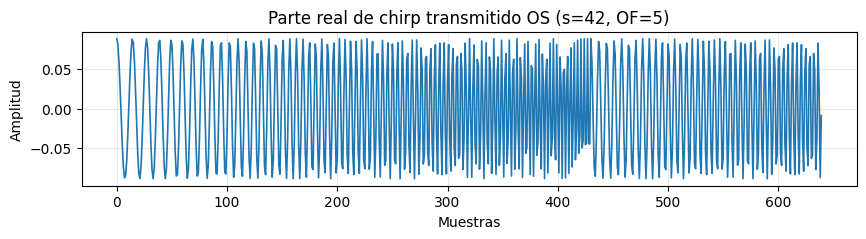

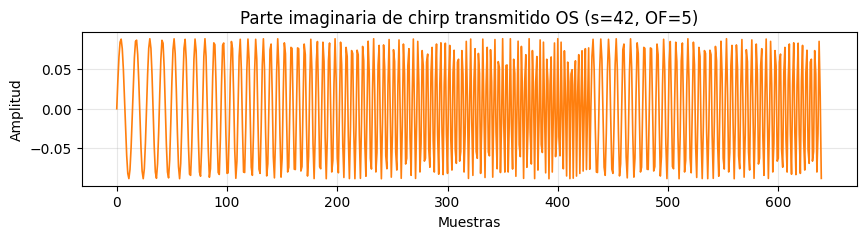

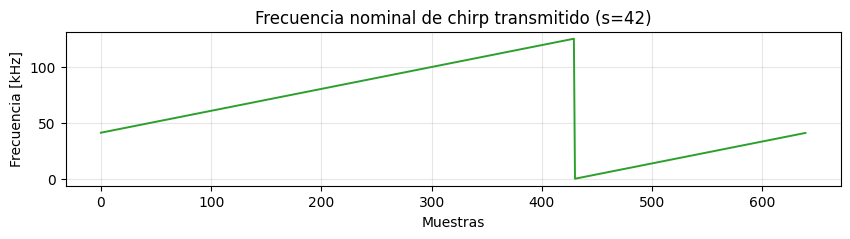

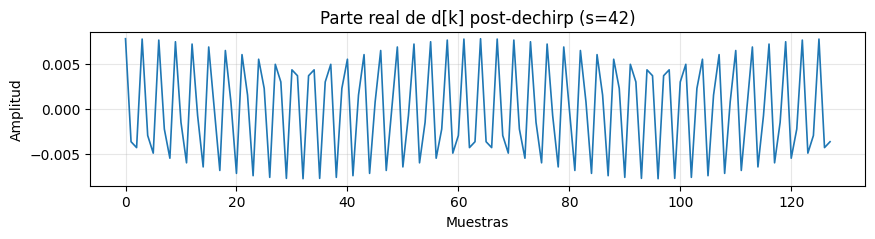

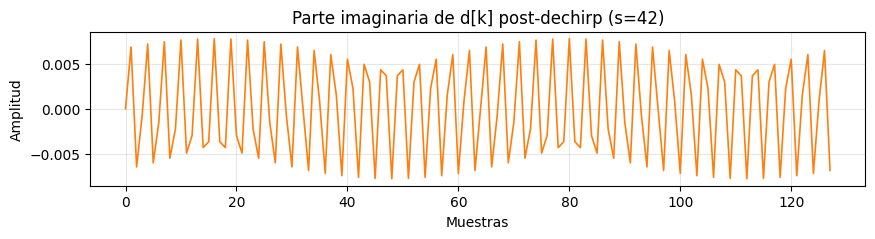

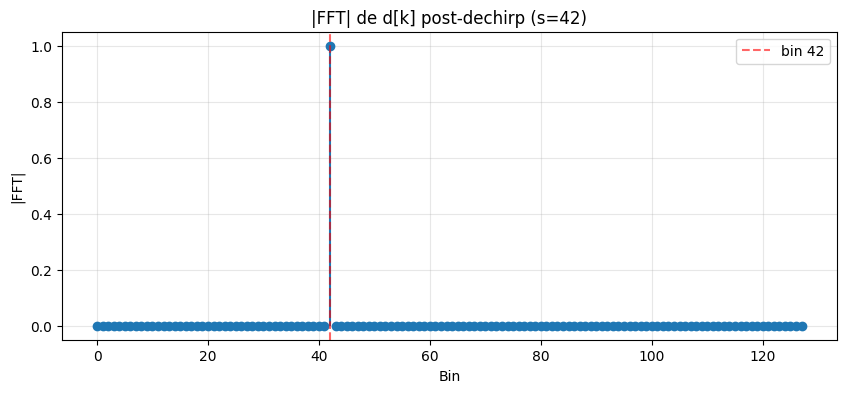

In [33]:
# Prueba de comunicación end-to-end (sin canal)
# Generamos bits aleatorios y los convertimos a símbolos con el codec del Módulo 1
# (en vez de generar símbolos directos, así integramos los dos módulos)

N_TEST   = 1000
num_bits = N_TEST * SF
bits_tx  = np.random.randint(0, 2, num_bits)
simbolos_tx = bits_to_symbols(bits_tx, SF)
simbolos_rx = np.zeros(N_TEST, int)

# Loop de transmisión/recepción
for i in range(len(simbolos_tx)):
    s = simbolos_tx[i]
    chirp = simbolo_a_chirp(s, SF)
    simbolos_rx[i] = chirp_a_simbolo(chirp, SF)


SER = calcular_ser(simbolos_tx, simbolos_rx)
errores = int(SER * N_TEST)

print(f"Prueba de comunicación ({N_TEST} símbolos, sin canal):")
print(f"  Símbolos TX (primeros 10): {simbolos_tx[:10]}")
print(f"  Símbolos RX (primeros 10): {simbolos_rx[:10]}")
print(f"  Errores: {errores}/{N_TEST}")
print(f"  SER = {SER}")


# === Inspección visual del primer símbolo ===
# Tomamos el primer símbolo del lote y mostramos las 4 etapas del sistema

s_demo = int(simbolos_tx[0])
M = 2 ** SF
k = np.arange(M)

print(f"\nGráfico del primer símbolo: s = {s_demo}")

# Generar las señales en cada etapa
chirp_tx = simbolo_a_chirp(s_demo, SF)

OF = 5
t,chirp_tx_os = simbolo_a_chirp_os(s_demo, SF, BW=125e3, OF=5)

down_chirp = np.exp(-1j * 2 * np.pi * k**2 / M) / np.sqrt(M)
dechirped = chirp_tx * down_chirp

# Etapa 1: chirp transmitido (Re/Im + frecuencia instantánea)
#plot_parte_real(chirp_tx, f"chirp transmitido (s={s_demo})")
plot_parte_real(chirp_tx_os, f"chirp transmitido OS (s={s_demo}, OF={OF})", BW, OF)
#plot_parte_imag(chirp_tx, f"chirp transmitido (s={s_demo})")
plot_parte_imag(chirp_tx_os, f"chirp transmitido OS (s={s_demo}, OF={OF})", BW, OF)
plot_frecuencia_nominal(s_demo, SF, f"chirp transmitido (s={s_demo})", BW, OF)
#plot_frecuencia_instantanea(chirp_tx, f"chirp transmitido (s={s_demo})")
#plot_frecuencia_instantanea(chirp_tx_os, f"chirp transmitido OS (s={s_demo}, OF={OF})", BW, OF)

# Etapa 2: señal post-dechirp (Re/Im) — debe ser una
plot_parte_real(dechirped, f"d[k] post-dechirp (s={s_demo})")
plot_parte_imag(dechirped, f"d[k] post-dechirp (s={s_demo})")

# Etapa 3: espectro |FFT(d)| — debe tener un pico en el bin s_demo
plot_fft(dechirped, f"d[k] post-dechirp (s={s_demo})", bin_marca=s_demo)

### Verificación de Ortonormalidad de los chirps

Se calcula la matriz de correlación entre los $M$ chirps y se verifica que sea la identidad.

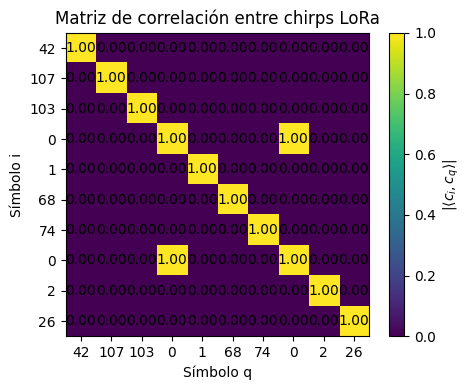

In [34]:
def matriz_correlacion_chirps(simbolos, SF):
    
    chirps = [simbolo_a_chirp(s, SF) for s in simbolos]
    N = len(simbolos)

    G = np.zeros((N, N))

    for i in range(N):
        for q in range(N):
            G[i, q] = np.abs(np.vdot(chirps[q], chirps[i]))

    return G


simbolos = list(simbolos_tx[:10])

G = matriz_correlacion_chirps(simbolos, SF)

plt.figure(figsize=(5, 4))
plt.imshow(G, origin="upper", vmin=0, vmax=1)

plt.colorbar(label=r"$|\langle c_i, c_q \rangle|$")
plt.xticks(np.arange(len(simbolos)), simbolos)
plt.yticks(np.arange(len(simbolos)), simbolos)

plt.title("Matriz de correlación entre chirps LoRa")
plt.xlabel("Símbolo q")
plt.ylabel("Símbolo i")

for i in range(len(simbolos)):
    for q in range(len(simbolos)):
        plt.text(q, i, f"{G[i, q]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

# Módulo 3 — Canal con Ruido AWGN

Este módulo agrega al sistema el **canal con ruido AWGN** (*Additive White Gaussian Noise*) que se suma a la señal entre el Waveform Former y el n-Tuple Former y luego medimos cómo cambia el desempeño del segundo a medida que varía la SNR. Validamos la implementación comparando los resultados con las curvas de BER publicadas en el paper de Vangelista.

---

## 1. ¿Qué es el ruido AWGN?

**AWGN** = Additive White Gaussian Noise. Tres propiedades clave:

- **A** (Additive): se suma a la señal: $r[k] = c_s[k] + n[k]$
- **W** (White):  su densidad espectral de potencia es plana (constante) en frecuencia.
- **G** (Gaussian): cada muestra es una variable aleatoria Gaussiana.

En tiempo discreto y banda base compleja, el ruido se modela como un vector aleatorio complejo:

$n[k] = n_r[k] + j \cdot n_i[k]$

donde $n_r[k]$ y $n_i[k]$ son Gaussianas independientes de media cero y varianza $\sigma^2/2$ cada una. La varianza total compleja es entonces $\sigma^2 = \sigma_r^2 + \sigma_i^2$.

## 2. Relación entre SNR y potencia del ruido

La **SNR** (Signal-to-Noise Ratio) se define como la relación entre la potencia de la señal y la potencia del ruido:

$\text{SNR}_{\text{lineal}} = \frac{P_{\text{señal}}}{P_{\text{ruido}}}$

**Conversión:**

$\text{SNR}_{\text{dB}} = 10 \log_{10}(\text{SNR}_{\text{lineal}})$

$\text{SNR}_{\text{lineal}} = 10^{\text{SNR}_{\text{dB}}/10}$


**Potencia de la señal discreta compleja:**

$P_{\text{señal}} = \frac{1}{N} \sum_{k=0}^{N-1} |c[k]|^2$

Como el chirp tiene energía unitaria ($\sum |c[k]|^2 = 1$) y tiene $M$ muestras, $P_{\text{señal}} = 1/M$.

**Potencia del ruido**, despejando:

$P_{\text{ruido}} = \frac{P_{\text{señal}}}{\text{SNR}_{\text{lineal}}}$

Como la potencia se reparte en partes iguales, entonces la potencia total del ruido complejo es $P_{\text{ruido}}$, donde cada componente  tiene varianza $\sigma_r^2 = \sigma_i^2 = P_{\text{ruido}}/2$. Por eso:

$\sigma = \sqrt{P_{\text{ruido}}/2}$

es la desviación estándar de cada componente (real e imaginaria), esto nos sirve para generar el ruido con NumPy.

## 3. Implementación de `agregar_ruido_awgn`

La función recibe la señal y la SNR en dB, y devuelve la señal con ruido sumado.

In [35]:
def agregar_ruido_awgn(senal, SNR_dB):
    # 1. Potencia de la señal (promedio de |señal|^2)
    P_senal = np.mean(np.abs(senal) ** 2)

    # 2. SNR lineal
    SNR_lineal = 10 ** (SNR_dB / 10)

    # 3. Potencia del ruido
    P_ruido = P_senal / SNR_lineal

    # 4. Generar ruido complejo: cada componente con varianza P_ruido/2
    sigma = np.sqrt(P_ruido / 2)
    ruido = sigma * (np.random.randn(*senal.shape) + 1j * np.random.randn(*senal.shape)) 

    # 5. Sumar ruido a la señal
    senal_ruidosa = senal + ruido

    return senal_ruidosa

## 4. Visualización del efecto del ruido

Generamos el chirp de un símbolo, le agregamos ruido a distintas SNR, y vemos cómo se deforma.

In [41]:
def plot_frecuencia_estimada_por_fase(signal, title, BW=125e3, OF=1, modo="muestras"):
    """
    Grafica una estimación de la frecuencia instantánea a partir
    de la diferencia de fase entre muestras consecutivas.

    A diferencia de la frecuencia nominal, esta sí depende de la señal.
    Por eso, si la señal tiene ruido, el gráfico también se ensucia.
    """

    signal = np.asarray(signal)

    fs = BW * OF

    # Cambio de fase muestra a muestra:
    # signal[k+1] * conj(signal[k]) = exp(j*(fase[k+1] - fase[k]))
    fase_inc = np.angle(signal[1:] * np.conj(signal[:-1]))

    # Conversión de rad/muestra a Hz
    freq_est = fase_inc / (2 * np.pi) * fs

    # La llevamos al rango [0, BW)
    # Para LoRa queremos visualizar dentro del ancho de banda.
    freq_est_positiva = freq_est % BW

    x, xlabel = obtener_eje_x(len(freq_est_positiva), BW, OF, modo)

    plt.figure(figsize=(10, 2))
    plt.plot(x, freq_est_positiva / 1e3, color='C3', linewidth=1.1)
    plt.title(f"Frecuencia estimada por fase de {title}")
    plt.xlabel(xlabel)
    plt.ylabel("Frecuencia [kHz]")
    plt.grid(True, alpha=0.3)
    plt.show()

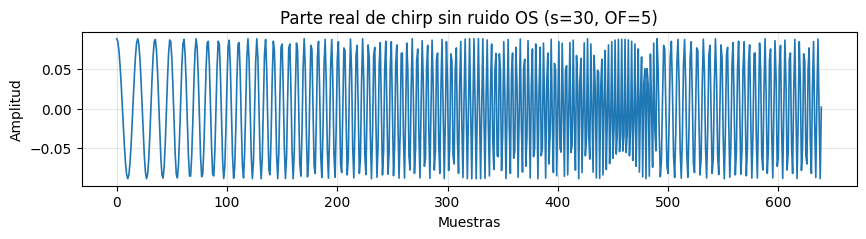

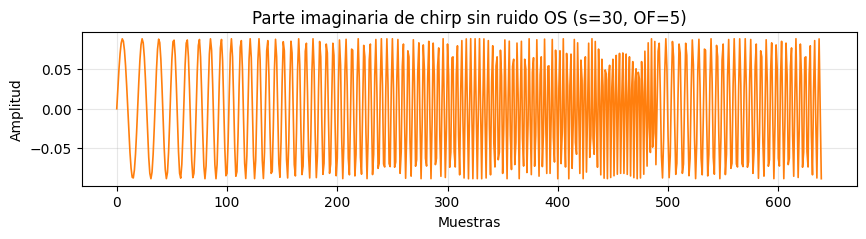

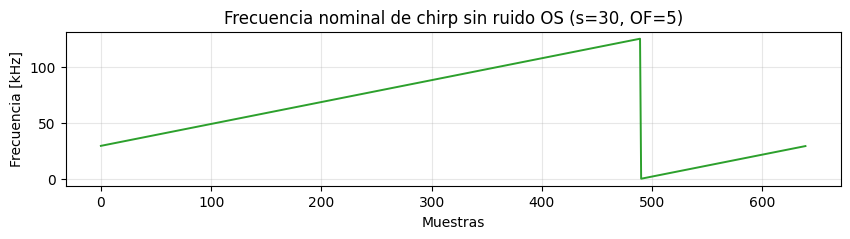

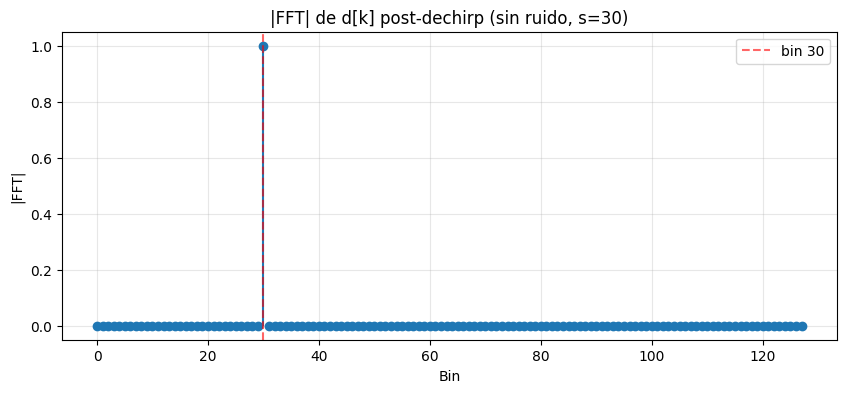

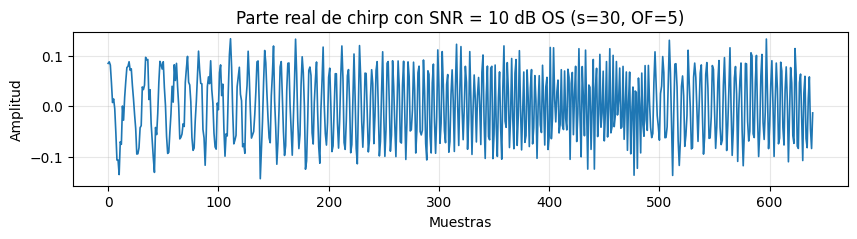

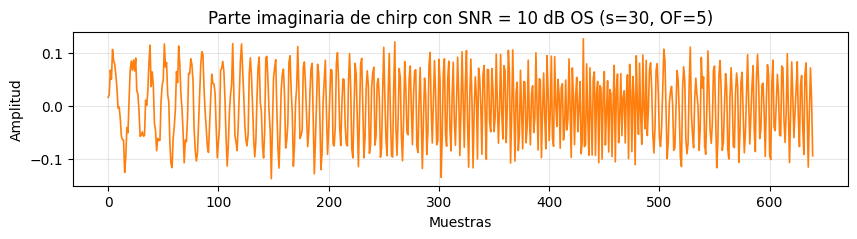

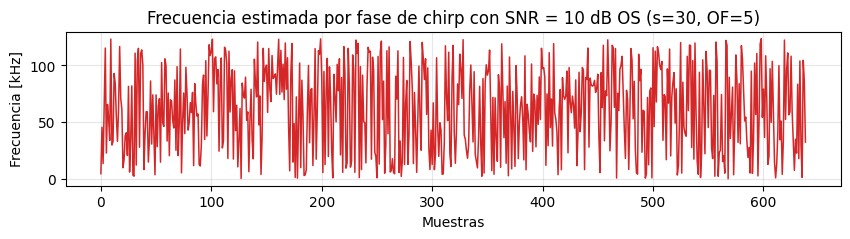

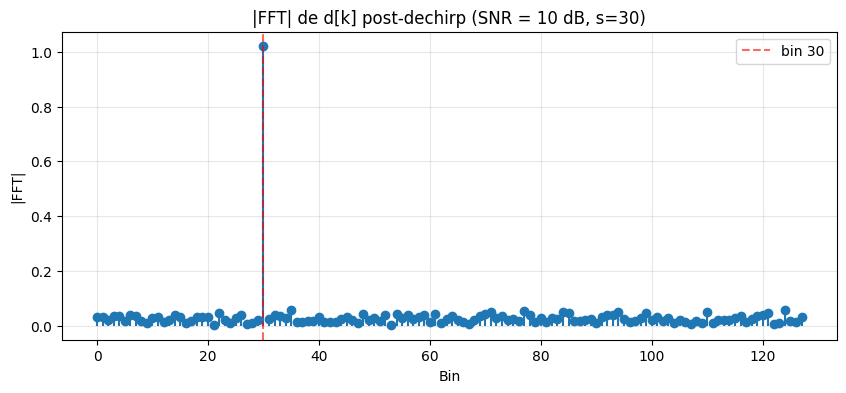

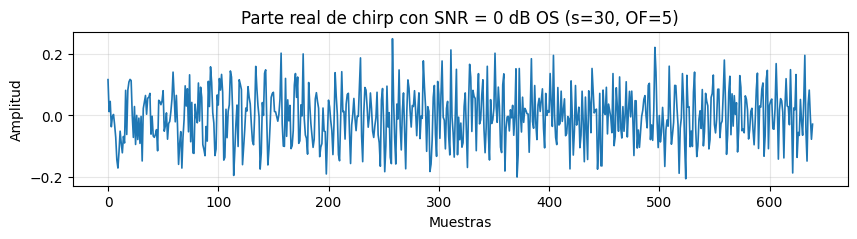

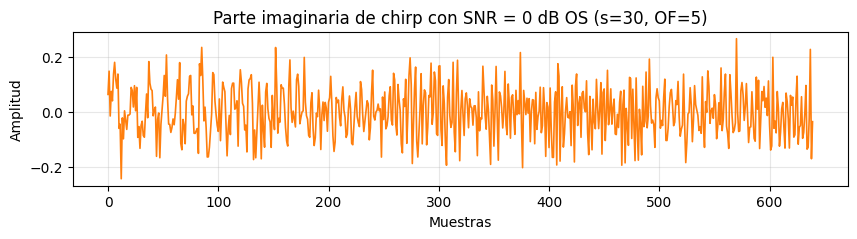

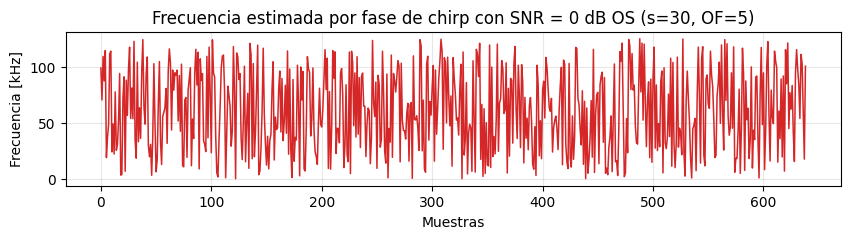

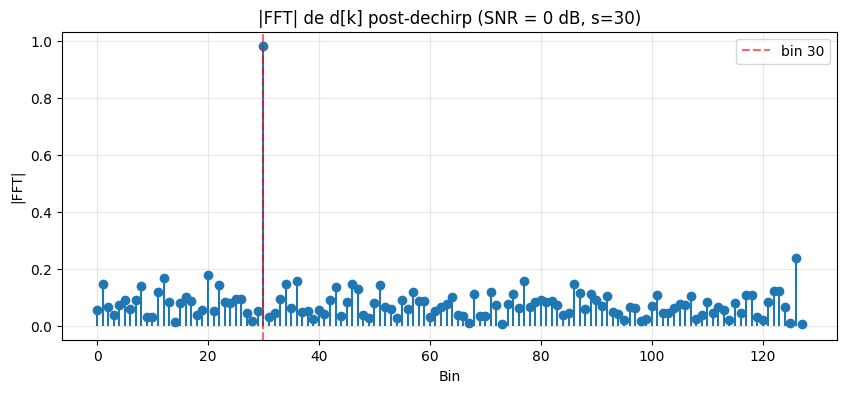

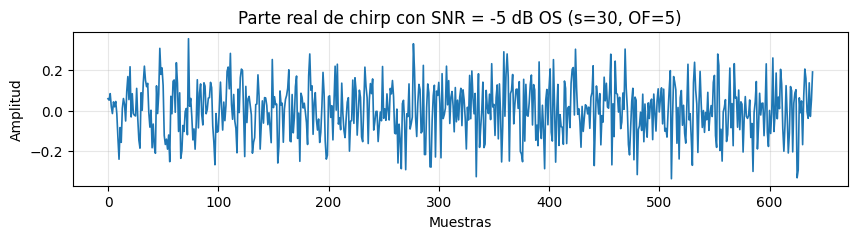

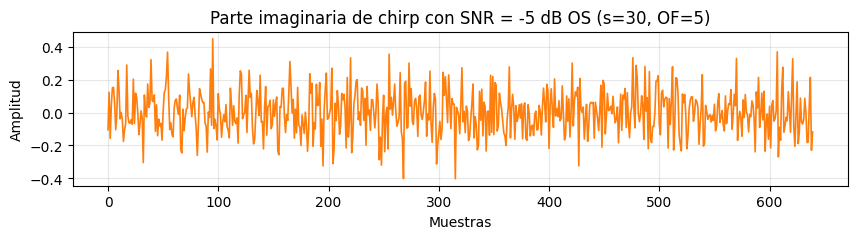

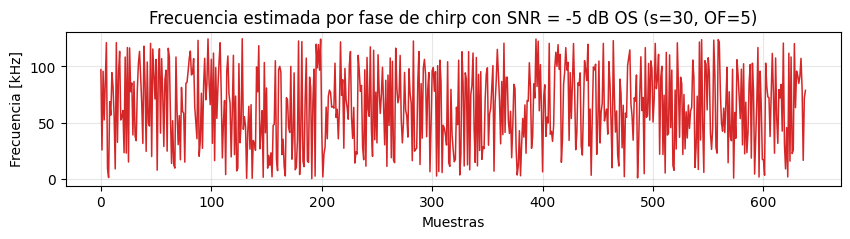

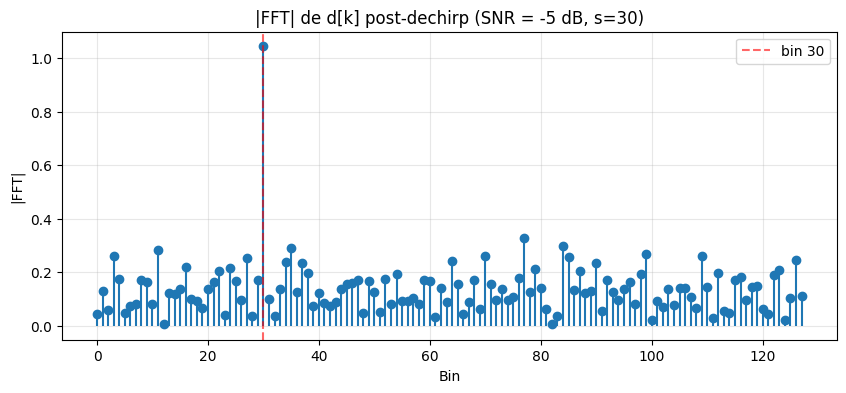

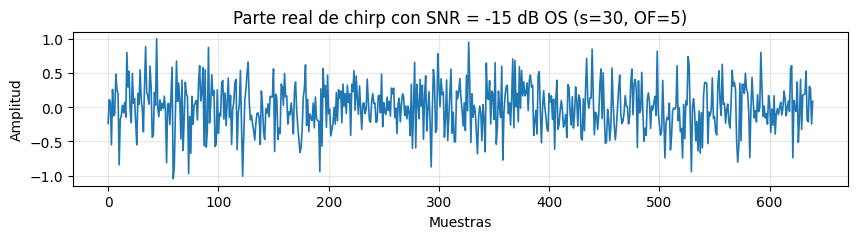

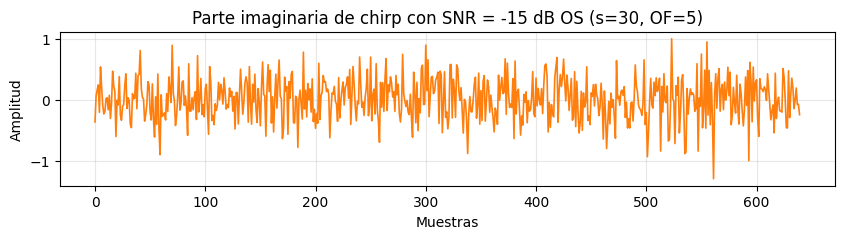

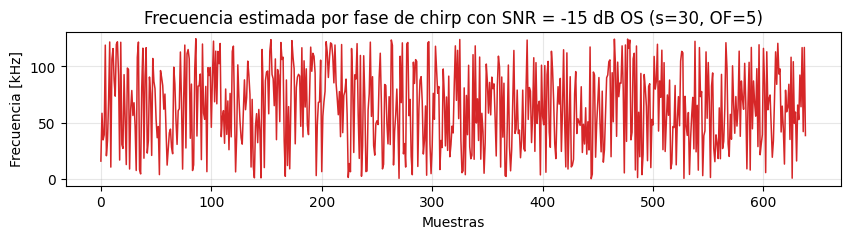

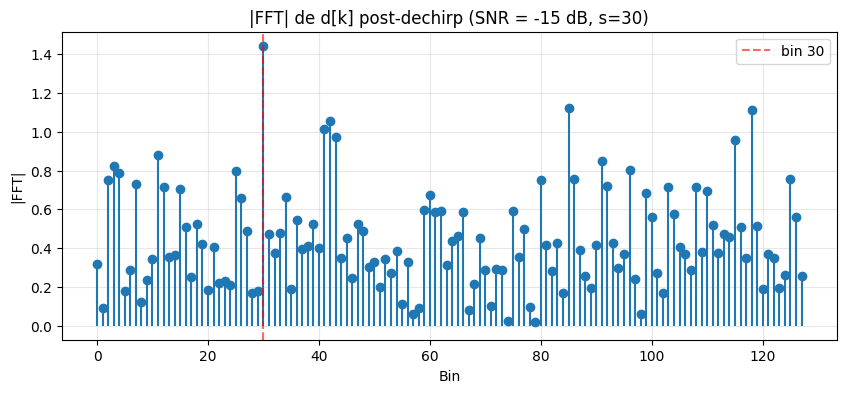

In [44]:
# Generar el chirp del símbolo de prueba (sin ruido) y su versión post-dechirp
s = 30
OF = 5
chirp_limpio = simbolo_a_chirp(s, SF)
t,chirp_limpio_os = simbolo_a_chirp_os(s, SF, BW=125e3, OF=OF)
down_chirp = np.exp(-1j * 2 * np.pi * k**2 / M) / np.sqrt(M)
dechirped_limpio = chirp_limpio * down_chirp

# Mostrar el chirp limpio en los 4 dominios
#plot_parte_real(chirp_limpio, f"chirp sin ruido (s={s})")
plot_parte_real(chirp_limpio_os, f"chirp sin ruido OS (s={s}, OF={OF})", BW, OF)
#plot_parte_imag(chirp_limpio, f"chirp sin ruido (s={s})")
plot_parte_imag(chirp_limpio_os, f"chirp sin ruido OS (s={s}, OF={OF})", BW, OF)
#plot_frecuencia_instantanea(chirp_limpio, f"chirp sin ruido (s={s})", BW)
plot_frecuencia_nominal(s, SF, f"chirp sin ruido OS (s={s}, OF={OF})", BW, OF)
plot_fft(dechirped_limpio, f"d[k] post-dechirp (sin ruido, s={s})", bin_marca=s)

# Mostrar el chirp ruidoso a distintas SNR
for snr in [10, 0,-5, -15]:
    chirp_ruidoso = agregar_ruido_awgn(chirp_limpio, snr)
    chirp_ruidoso_os = agregar_ruido_awgn(chirp_limpio_os, snr)
    dechirped = chirp_ruidoso * down_chirp
    #plot_parte_real(chirp_ruidoso, f"chirp con SNR = {snr} dB (s={s})")
    plot_parte_real(chirp_ruidoso_os, f"chirp con SNR = {snr} dB OS (s={s}, OF={OF})", BW, OF)
    #plot_parte_imag(chirp_ruidoso, f"chirp con SNR = {snr} dB (s={s})")
    plot_parte_imag(chirp_ruidoso_os, f"chirp con SNR = {snr} dB OS (s={s}, OF={OF})", BW, OF)
    #plot_frecuencia_instantanea(chirp_ruidoso, f"chirp con SNR = {snr} dB (s={s})", BW)
    #plot_frecuencia_instantanea(chirp_ruidoso, f"chirp con SNR = {snr} dB (s={s})", BW)
    plot_frecuencia_estimada_por_fase(
    chirp_ruidoso_os,
    f"chirp con SNR = {snr} dB OS (s={s}, OF={OF})",
    BW,
    OF
)
    plot_fft(dechirped, f"d[k] post-dechirp (SNR = {snr} dB, s={s})", bin_marca=s)

**Observaciones — efecto del ruido en cada dominio:**

A medida que baja la SNR podemos observar los efectos tanto en el dominio del **tiempo** como en el dominio de la **frecuencia**:

| SNR | En el tiempo (Re/Im/freq inst.) | En frecuencia (FFT post-dechirp) |
|---|---|---|
| **Sin ruido** | chirp limpio | pico aislado en bin $s$ |
| **20 dB (alta)** | chirp muy parecido al limpio |  bin dominante con otros bins ruidosos muy bajos |
| **10 dB (media)** | ruido visible | seguimos con un bin máximo pero bins ruidosos se agrandan |
| **-5 dB (baja)** | chirp enterrado en ruido visualmente | Un bin todavía domina |
| **-15 dB (muy baja)** | señal totalmente confundida con ruido | El bin maximo gana en promedio pero los bins ruidosos son muy parecidos por lo que hay errores frecuentes |

## 5. Simulación Monte Carlo de BER y SER vs SNR

Ahora medimos el desempeño completo del sistema (TX → AWGN → RX) variando la SNR.

Entonces para cada valor de SNR, transmitimos $N$ símbolos aleatorios, lo recuperamos con el demodulador, y contamos errores. Podremos observar como el BER se aproxima al SER como $\text{BER} \approx \frac{M/2}{M-1} \cdot \text{SER} \approx \frac{1}{2} \text{SER}$ para $M$ grande.

In [45]:
def simular_ber_ser_vs_snr(SF, SNR_dB_range, num_simbolos):

    num_bits = num_simbolos * SF

    SERs = []
    BERs = []

    print(f"{'SNR (dB)':<10} {'SER':<14} {'BER':<14} {'Errores símbolos'}") #f"{'SNR (dB)':<10} sig
    print("-" * 60)

    for SNR_dB in SNR_dB_range:
        # 1. Generar bits aleatorios
        bits_tx = np.random.randint(0, 2, num_bits)

        # 2. Codificar bits -> símbolos
        simbolos_tx = bits_to_symbols(bits_tx, SF)

        # 3. Para cada símbolo: modular, agregar ruido, demodular
        simbolos_rx = np.zeros(num_simbolos, int)
        for i in range(len(simbolos_tx)):
            s = simbolos_tx[i]
            chirp = simbolo_a_chirp(s, SF)
            chirp_ruidoso = agregar_ruido_awgn(chirp, SNR_dB)
            simbolos_rx[i] = chirp_a_simbolo(chirp_ruidoso, SF)


        # 4. Decodificar símbolos -> bits
        bits_rx = symbols_to_bits(simbolos_rx, SF)

        # 5. Calcular métricas usando las funciones del sistema
        ser = calcular_ser(simbolos_tx, simbolos_rx)
        ber = calcular_ber(bits_tx, bits_rx)

        SERs.append(ser)
        BERs.append(ber)
        errores_simb = int(ser * num_simbolos)
        print(f"{SNR_dB:<10.1f} {ser:<16.6f} {ber:<16.6f} {errores_simb} / {num_simbolos}")
    return np.array(SERs), np.array(BERs)

# Ejecución del Monte Carlo
SNR_dB_range = np.arange(-12, -2, 1.0)
num_simbolos = 100000

print(f"\n=== Monte Carlo: SF={SF}, BW={BW/1e3:.0f} kHz, {num_simbolos} símbolos por SNR ===\n")
SERs_simulados, BERs_simulados = simular_ber_ser_vs_snr(SF, SNR_dB_range, num_simbolos)



=== Monte Carlo: SF=7, BW=125 kHz, 100000 símbolos por SNR ===

SNR (dB)   SER            BER            Errores símbolos
------------------------------------------------------------
-12.0      0.203870         0.103224         20387 / 100000
-11.0      0.099970         0.050099         9997 / 100000
-10.0      0.037140         0.018476         3714 / 100000
-9.0       0.009760         0.004983         976 / 100000
-8.0       0.001530         0.000800         153 / 100000
-7.0       0.000130         0.000066         12 / 100000
-6.0       0.000000         0.000000         0 / 100000
-5.0       0.000000         0.000000         0 / 100000
-4.0       0.000000         0.000000         0 / 100000
-3.0       0.000000         0.000000         0 / 100000


## 6. Comparación con la curva del paper Vangelista

Para validar la implementación, comparamos los resultados con las curvas de BER publicadas en el paper Vangelista, Figura 1. La imagen muestra el desempeño teórico de la modulación FSCM sobre canal Flat (AWGN) y sobre canal Selectivo en Frecuencia.

C:\Users\franco\AppData\Local\Temp\ipykernel_23428\2043235578.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


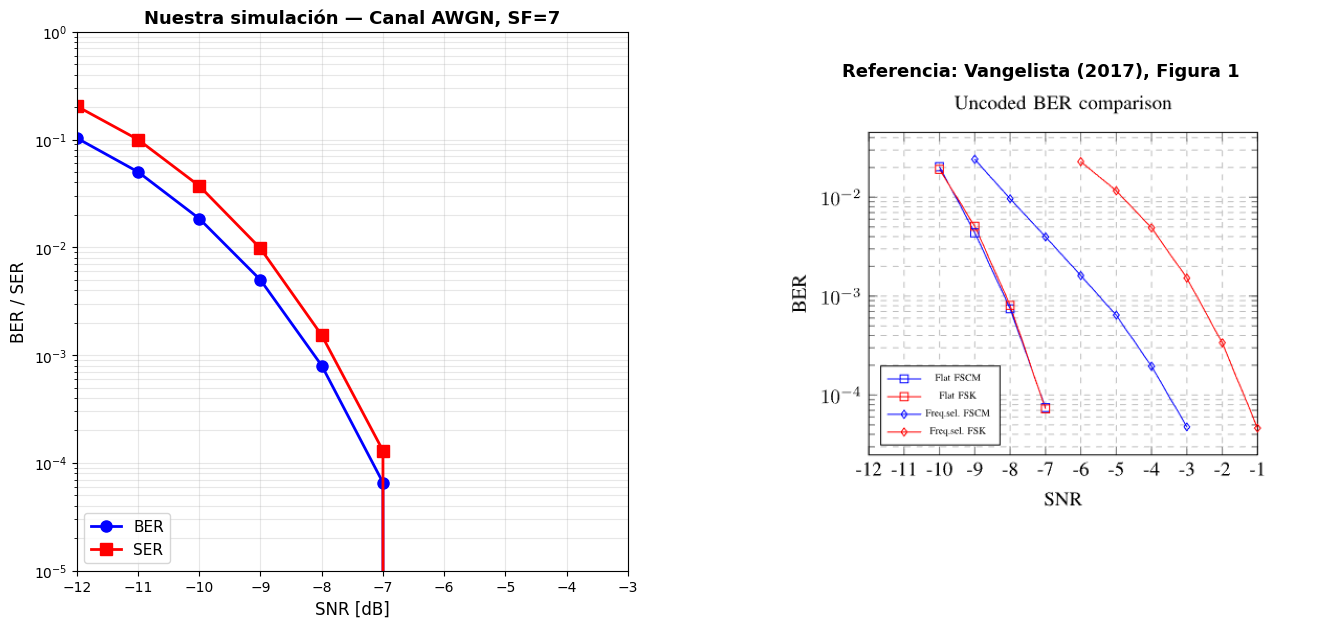

In [46]:
# Layout side-by-side: nuestra simulación vs imagen del paper
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

# Panel izquierdo: nuestra simulación
ax1 = fig.add_subplot(gs[0, 0])
ax1.semilogy(SNR_dB_range, BERs_simulados, 'o-', label='BER', markersize=8, linewidth=2, color='blue')
ax1.semilogy(SNR_dB_range, SERs_simulados, 's-', label='SER', markersize=8, linewidth=2, color='red')
ax1.set_xlabel('SNR [dB]', fontsize=12)
ax1.set_ylabel('BER / SER', fontsize=12)
ax1.set_title(f'Nuestra simulación — Canal AWGN, SF={SF}', fontsize=13, fontweight='bold')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(fontsize=11, loc='lower left')
ax1.set_xlim([SNR_dB_range[0], SNR_dB_range[-1]])
ax1.set_ylim([1e-5, 1])

# Panel derecho: imagen del paper
ax2 = fig.add_subplot(gs[0, 1])
try:
    img = imread('BER.png')
    ax2.imshow(img)
    ax2.set_title('Referencia: Vangelista (2017), Figura 1', fontsize=13, fontweight='bold')
    ax2.axis('off')
except FileNotFoundError:
    ax2.text(0.5, 0.5, 'Imagen BER.png no encontrada\nen la carpeta del notebook',
             ha='center', va='center', fontsize=14, transform=ax2.transAxes)
    ax2.axis('off')

plt.tight_layout()
plt.show()

# Módulo 4 — Canal Selectivo en Frecuencia

---

## 1. ¿Qué es un canal selectivo en frecuencia?

En el anterior modulo trabajamos con un canal AWGN: agrega ruido pero no distorsiona la señal. Un canal real, suele tener **multipath** que significa que la señal llega al receptor por varios caminos físicos, cada uno con su propio delay y atenuación

Cuando esas copias se suman, el resultado depende de la frecuencia: en algunas se suman (interferencia constructiva, **+dB**) y en otras se cancelan (destructiva, **−dB**). El canal "selecciona" frecuencias.

Matemáticamente, un canal selectivo se modela como un sistema LTI con **respuesta al impulso** $h(nT)$ que tiene varias componentes (uno por camino físico). La salida del canal es la **convolución** de la señal transmitida con $h$:

$$r(nT) = (h \ast s)(nT) + w(nT)$$

donde $w$ es el ruido AWGN del Módulo 3.

## 2. La respuesta al impulso h(nT) de Vangelista

$$h(nT) = \sqrt{0.8}\,\delta(nT) + \sqrt{0.2}\,\delta(nT - T)$$

Como el canal *convoluciona* la señal con $h$, y convolucionar en el tiempo equivale a *multiplicar en frecuencia* ($Y=X\cdot H$). Entonces tomando tomamos $H(f)=\text{FFT}(h)$, y su módulo al cuadrado $|H(f)|^2$ porque lo que importa es la potencia que pasa en cada frecuencia, entonces:

$$|H(f)|^2 = 1 + 0.8\cos(2\pi f T)$$



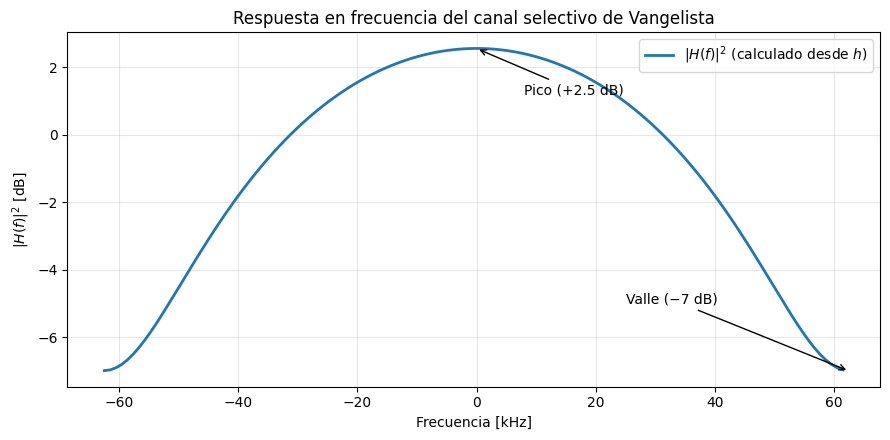

In [47]:
# Misma h que usa agregar_canal_selectivo
h_canal = np.array([np.sqrt(0.8), np.sqrt(0.2)])

# 1) Transformada de h  -> respuesta en frecuencia
Nfft = 128
H = np.fft.fft(h_canal, Nfft)

# 2) Módulo al cuadrado -> respuesta en potencia, y en dB
H2_dB = 10 * np.log10(np.abs(H)**2)

# Eje de frecuencia en kHz (BW de LoRa = 125 kHz), centrado en 0
f = np.fft.fftshift(np.fft.fftfreq(Nfft, 1/BW)) / 1e3
H2_dB = np.fft.fftshift(H2_dB)

plt.figure(figsize=(9, 4.5))
plt.plot(f, H2_dB, lw=2, label=r'$|H(f)|^2$ (calculado desde $h$)')
plt.annotate('Pico (+2.5 dB)', xy=(0, 2.55), xytext=(8, 1.2),
             arrowprops=dict(arrowstyle='->'))
plt.annotate('Valle (−7 dB)', xy=(62.5, -7), xytext=(25, -5),
             arrowprops=dict(arrowstyle='->'))
plt.title('Respuesta en frecuencia del canal selectivo de Vangelista')
plt.xlabel('Frecuencia [kHz]'); plt.ylabel(r'$|H(f)|^2$ [dB]')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
plt.show()

## 3. Implementación de `agregar_canal_selectivo`

La función toma una señal (un chirp) y la convoluciona con $h(nT)$.

In [48]:
def agregar_canal_selectivo(senal):
    # h(nT) = √0.8·δ(nT) + √0.2·δ(nT-T): camino directo + eco a 1 chip
    h_canal = np.array([np.sqrt(0.8), np.sqrt(0.2)])

    # mode='same' mantiene len(salida) == len(entrada)
    senal_convolucionada = np.convolve(senal, h_canal, 'same') #en vez de same

    return senal_convolucionada

## 4. Visualización del efecto del canal selectivo

Tomamos un chirp limpio (símbolo de prueba) y lo pasamos por el canal. Vemos cómo se modifica en tiempo y cómo afecta al dechirp + FFT (que es lo que ve el receptor LoRa).

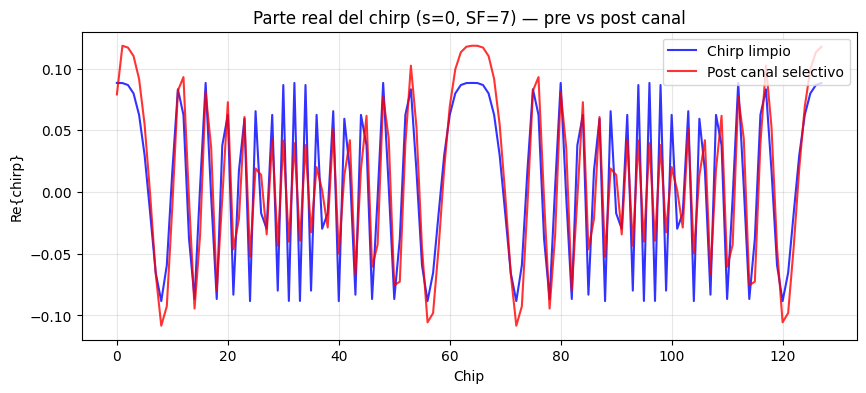

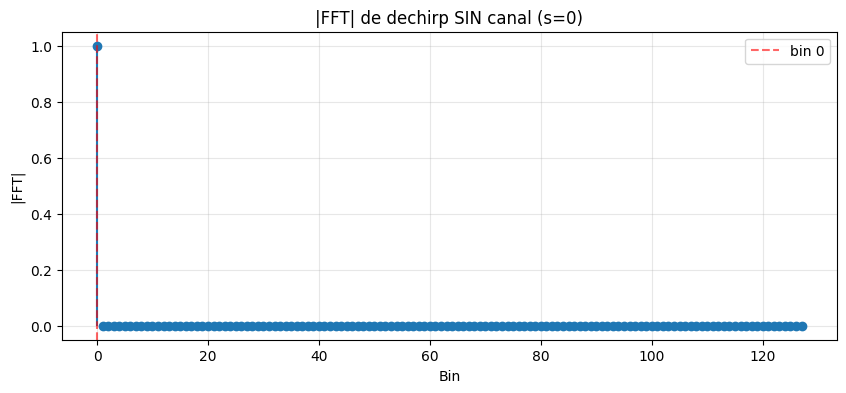

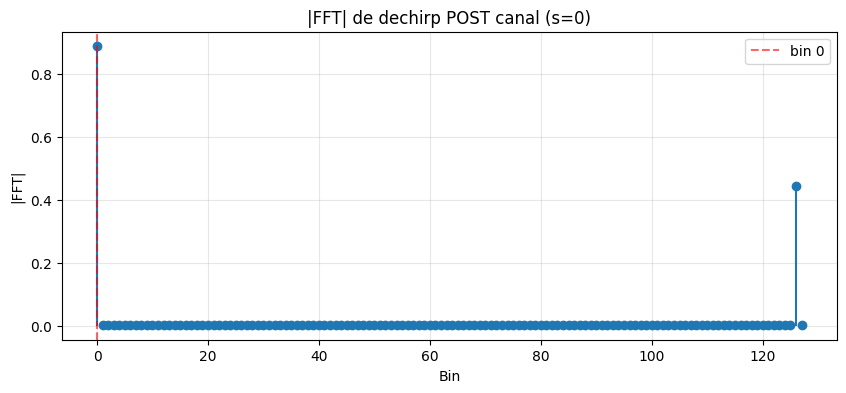

In [49]:
# Parámetros de la visualización
s_test = 0  # símbolo de prueba

# 1. Chirp limpio y su versión post-canal
chirp_limpio = simbolo_a_chirp(s_test, SF)
chirp_canal  = agregar_canal_selectivo(chirp_limpio)

# 2. Dechirp (lo que ve el receptor) = chirp * conjugado del chirp base
chirp_base_conj = np.conj(simbolo_a_chirp(0, SF))
dechirp_limpio  = chirp_limpio * chirp_base_conj
dechirp_canal   = chirp_canal  * chirp_base_conj

# --- Panel 1: parte real pre/post canal (overlay custom para comparar las dos) ---
plt.figure(figsize=(10, 4))
plt.plot(np.real(chirp_limpio), 'b-', label='Chirp limpio',         alpha=0.8, lw=1.5)
plt.plot(np.real(chirp_canal),  'r-', label='Post canal selectivo', alpha=0.8, lw=1.5)
plt.title(f'Parte real del chirp (s={s_test}, SF={SF}) — pre vs post canal')
plt.xlabel('Chip'); plt.ylabel('Re{chirp}')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# --- Espectros del dechirp: reutilizamos plot_fft (paneles 2 y 3) ---
plot_fft(dechirp_limpio, f'dechirp SIN canal (s={s_test})',  bin_marca=s_test)
plot_fft(dechirp_canal,  f'dechirp POST canal (s={s_test})', bin_marca=s_test)

## 5. Simulación Monte Carlo de BER y SER vs SNR — con canal selectivo

Mismo loop que el Módulo 3, pero agregando el canal selectivo antes del ruido AWGN (el canal actúa sobre la señal transmitida, no sobre el ruido propio del receptor):

Procesamos **per-símbolo** (cada chirp por separado), igual que en el Módulo 3. Esta convención captura la distorsión intra-símbolo causada por el multipath; no incluye ISI entre símbolos consecutivos (con 2 componentes y delay = 1 chip sería pequeña de todos modos).

In [50]:
def simular_ber_ser_vs_snr_selectivo(SF, SNR_dB_range, num_simbolos):

    M = 2 ** SF
    num_bits = num_simbolos * SF

    SERs = []
    BERs = []

    print(f"{'SNR (dB)':<10} {'SER':<16} {'BER':<16} {'Errores símbolos'}")
    print("-" * 60)

    for SNR_dB in SNR_dB_range:
        # 1. Generar bits aleatorios
        bits_tx = np.random.randint(0, 2, size=num_bits)

        # 2. Codificar bits -> símbolos
        simbolos_tx = bits_to_symbols(bits_tx, SF)

        # 3. Para cada símbolo: modular -> canal selectivo -> AWGN -> demodular
        simbolos_rx = np.zeros(num_simbolos, dtype=int)
        for i in range(len(simbolos_tx)):
            s = simbolos_tx[i]
            chirp = simbolo_a_chirp(s, SF)
            chirp_canal = agregar_canal_selectivo(chirp)              # canal selectivo primero
            chirp_ruidoso = agregar_ruido_awgn(chirp_canal, SNR_dB)   # después AWGN
            simbolos_rx[i] = chirp_a_simbolo(chirp_ruidoso, SF)

        # 4. Decodificar símbolos -> bits
        bits_rx = symbols_to_bits(simbolos_rx, SF)

        # 5. Calcular métricas
        ser = calcular_ser(simbolos_tx, simbolos_rx)
        ber = calcular_ber(bits_tx, bits_rx)

        SERs.append(ser) #append sirv
        BERs.append(ber)
        errores_sim = int(ser * num_simbolos)
        print(f"{SNR_dB:<10.1f} {ser:<14.6f} {ber:<14.6f} {errores_sim} / {num_simbolos}")

    return np.array(SERs), np.array(BERs)


# Ejecución del Monte Carlo — canal selectivo
SNR_dB_range_sel = np.arange(-12, -2, 1.0)  # mismo rango que AWGN para comparar
num_simbolos_sel = 100000

print(f"\n=== Monte Carlo CANAL SELECTIVO: SF={SF}, BW={BW/1e3:.0f} kHz, {num_simbolos_sel} símbolos por SNR ===\n")
SERs_selectivo, BERs_selectivo = simular_ber_ser_vs_snr_selectivo(SF, SNR_dB_range_sel, num_simbolos_sel)


=== Monte Carlo CANAL SELECTIVO: SF=7, BW=125 kHz, 100000 símbolos por SNR ===

SNR (dB)   SER              BER              Errores símbolos
------------------------------------------------------------
-12.0      0.346060       0.163710       34606 / 100000
-11.0      0.224760       0.102733       22476 / 100000
-10.0      0.124420       0.053250       12442 / 100000
-9.0       0.063500       0.024601       6350 / 100000
-8.0       0.028950       0.009771       2895 / 100000
-7.0       0.013100       0.003869       1310 / 100000
-6.0       0.005450       0.001483       545 / 100000
-5.0       0.002440       0.000624       244 / 100000
-4.0       0.000640       0.000170       64 / 100000
-3.0       0.000180       0.000044       18 / 100000


## 6. Comparación con la curva del paper Vangelista (Freq.sel. FSCM)

C:\Users\franco\AppData\Local\Temp\ipykernel_23428\3444699979.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


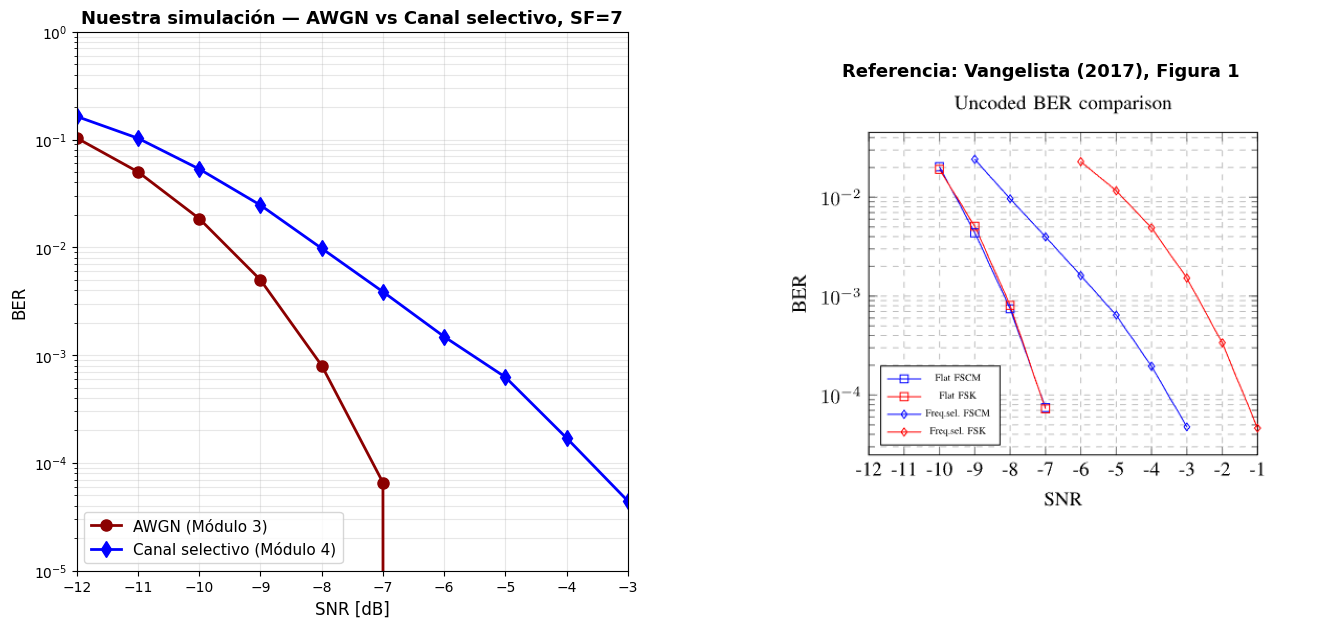

In [51]:
# Layout side-by-side: nuestras curvas vs imagen del paper
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

# Panel izquierdo: nuestras curvas — AWGN vs Selectivo
ax1 = fig.add_subplot(gs[0, 0])
ax1.semilogy(SNR_dB_range,     BERs_simulados, 'o-', label='AWGN (Módulo 3)',            markersize=8, linewidth=2, color='darkred')
ax1.semilogy(SNR_dB_range_sel, BERs_selectivo, 'd-', label='Canal selectivo (Módulo 4)', markersize=8, linewidth=2, color='blue')
ax1.set_xlabel('SNR [dB]', fontsize=12)
ax1.set_ylabel('BER', fontsize=12)
ax1.set_title(f'Nuestra simulación — AWGN vs Canal selectivo, SF={SF}', fontsize=13, fontweight='bold')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(fontsize=11, loc='lower left')
ax1.set_xlim([SNR_dB_range_sel[0], SNR_dB_range_sel[-1]])
ax1.set_ylim([1e-5, 1]) 

# Panel derecho: imagen del paper
ax2 = fig.add_subplot(gs[0, 1])
try:
    img = imread('BER.png')
    ax2.imshow(img)
    ax2.set_title('Referencia: Vangelista (2017), Figura 1', fontsize=13, fontweight='bold')
    ax2.axis('off')
except FileNotFoundError:
    ax2.text(0.5, 0.5, 'Imagen BER.png no encontrada\nen la carpeta del notebook',
             ha='center', va='center', fontsize=14, transform=ax2.transAxes)
    ax2.axis('off')

plt.tight_layout()
plt.show()